# **Convolución 1D**

Este cuaderno explora las capas convolucionales 1D.

Ejecuta las celdas en orden. En varios lugares verás la palabra "TAREA": sigue esas instrucciones, anticipa qué ocurrirá o escribe el código necesario para completar las funciones.


**Nota**

En estas funciones usaremos la convención habitual de dilatación: una dilatación de 1 aplica el filtro sobre elementos contiguos; una dilatación de 2 deja un espacio entre elementos consecutivos del filtro.

In [95]:
import numpy as np
import matplotlib.pyplot as plt

In [96]:
# Define una señal a la que aplicaremos convolución
x = [5.2, 5.3, 5.4, 5.1, 10.1, 10.3, 9.9, 10.3, 3.2, 3.4, 3.3, 3.1]

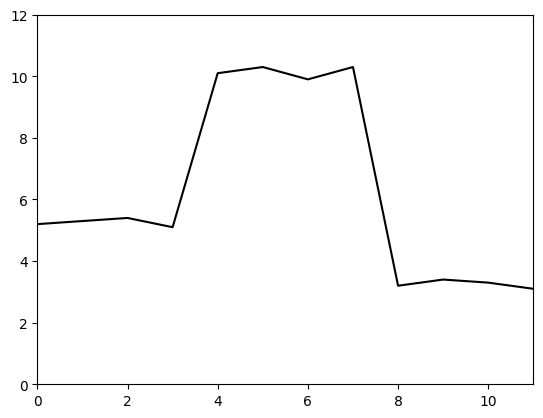

In [97]:
# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
plt.show()

In [98]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 1 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
# Recuerda que los arreglos de Python se indexan desde cero.
def conv_3_1_1_zp(x_in, omega):
    x_out = np.zeros_like(x_in)
    # TAREA -- escribe esta función
    # reemplaza esta línea
    x_out = x_out



    return x_out

In [99]:
import numpy as np

def my_conv1d(x_in, w):
    # Longitudes
    N = len(x_in)
    K = len(w)

    # Salida inicializada en ceros
    x_out = np.zeros(N)

    # Recorremos cada posición de la señal
    for i in range(N):
        acc = 0.0
        for j in range(K):
            # Índice de la señal considerando el desplazamiento
            idx = i + j - K//2   # centramos el kernel

            if 0 <= idx < N:
                acc += x_in[idx] * w[j]
            else:
                acc += 0.0  # relleno con ceros
        x_out[i] = acc

    return x_out


Ahora veamos qué tipo de operaciones puede hacer una convolución.
Primero puede promediar valores cercanos y suavizar la función:

La suma de la salida es 0.0, debe ser 71.1


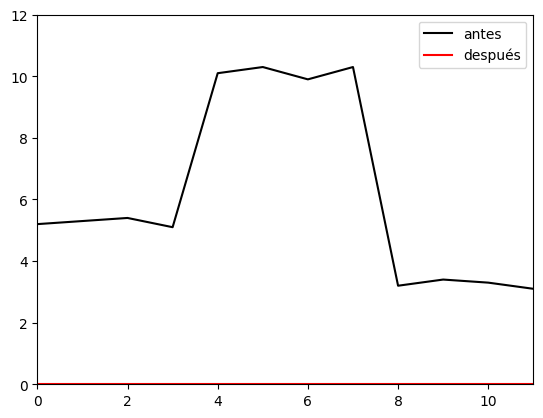

In [100]:

omega = [0.33,0.33,0.33]
h = conv_3_1_1_zp(x, omega)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h):3.3}, debe ser 71.1")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

Observa que la función roja es una versión suavizada de la negra, porque promedia valores adyacentes. Sin embargo, las primeras y últimas salidas son bastante menores que la curva original. Asegúrate de entender por qué.<br><br>

Con pesos diferentes, la convolución puede detectar cambios bruscos en la función:

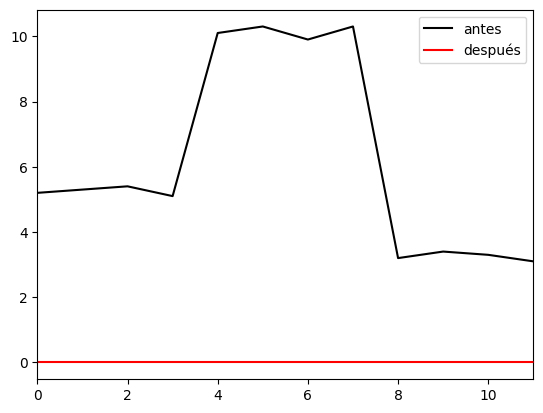

In [101]:

omega = [-0.5,0,0.5]
h2 = conv_3_1_1_zp(x, omega)

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h2, 'r-',label='después')
ax.set_xlim(0,11)
# ax.set_ylim(0, 12)
ax.legend()
plt.show()

Observa que la convolución produce un pico donde la función original sube y un valle donde baja. Es aproximadamente cero donde la función es localmente plana; por eso esta convolución aproxima una derivada. <br><br>

Ahora definamos algunas convoluciones con distintos parámetros.

In [102]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 2 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
def conv_3_2_1_zp(x_in, omega):
    x_out = np.zeros(int(np.ceil(len(x_in)/2)))
    # TAREA -- escribe esta función
    # reemplaza esta línea
    x_out = x_out



    return x_out

In [103]:
import numpy as np

def conv_3_1_1_zp(x_in, omega):
    # kernel size 3, stride 1, dilation 1, zero padding, output same length as input
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    N = len(x)
    K = len(w)  # should be 3
    pad = K // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    x_out = np.zeros_like(x)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        x_out[i] = acc
    return x_out

def conv_3_2_1_zp(x_in, omega):
    # kernel size 3, stride 2, dilation 1, zero padding
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    N = len(x)
    K = len(w)  # 3
    pad = K // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    # output length: ceil(N / stride)
    stride = 2
    out_len = int(np.ceil(N / stride))
    x_out = np.zeros(out_len)
    out_idx = 0
    for i in range(0, N, stride):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        x_out[out_idx] = acc
        out_idx += 1
    return x_out

def conv_5_1_1_zp(x_in, omega):
    # kernel size 5, stride 1, dilation 1, zero padding, output same length as input
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    N = len(x)
    K = len(w)  # should be 5
    pad = K // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    x_out = np.zeros_like(x)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        x_out[i] = acc
    return x_out

def conv_3_1_2_zp(x_in, omega):
    # kernel size 3, stride 1, dilation 2, zero padding, output same length as input
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    N = len(x)
    K = len(w)  # 3
    dilation = 2
    # effective kernel span = (K-1)*dilation + 1
    span = (K - 1) * dilation + 1
    pad = span // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    x_out = np.zeros_like(x)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            idx = i + j * dilation
            acc += x_padded[idx] * w[j]
        x_out[i] = acc
    return x_out

def get_conv_mat_3_1_1_zp(n_out, omega):
    # Construye la matriz de convolución (n_out x n_out) para kernel de tamaño 3,
    # stride 1, dilatación 1 y padding con ceros (salida same length)
    omega = np.asarray(omega, dtype=float)
    K = len(omega)  # 3
    pad = K // 2
    M = np.zeros((n_out, n_out), dtype=float)
    for row in range(n_out):
        for k in range(K):
            col = row + k - pad
            if 0 <= col < n_out:
                M[row, col] = omega[k]
    return M


In [104]:
omega = [0.33,0.33,0.33]
h3 = conv_3_2_1_zp(x, omega)

# Si lo hiciste bien, la longitud de salida debe ser seis y debe
# contener uno de cada dos valores de la convolución original con paso 1
print(h)
print(h3)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 3.465  5.214  8.415 10.065  5.577  3.234]


In [105]:
# Definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 5, paso 1 y dilatación 1.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
def conv_5_1_1_zp(x_in, omega):
    x_out = np.zeros_like(x_in)
    # TAREA -- escribe esta función
    # reemplaza esta línea
    x_out = x_out



    return x_out

my_conv1d (avg3): [ 3.5    5.3    5.267  6.867  8.7   10.3   10.2    7.667  5.433  3.3
  3.3    3.267  2.133]
conv_3_1_2_p (avg3), len: 7 values: [ 3.5    5.267  8.7   10.2    5.433  3.3    2.133]
conv_5_1_1_zp (avg5): [3.18 4.2  6.22 7.36 8.28 9.16 8.8  7.42 5.92 4.6  3.26 2.6  1.96]
max abs diff conv vs mat: 8.881784197001252e-16


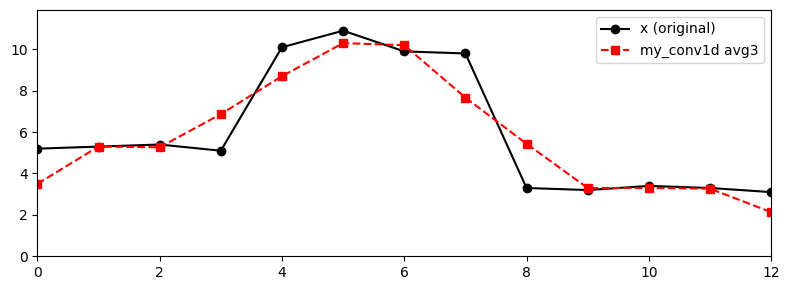

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Función genérica de conv 1D (zero padding), centrada, stride=1, dilation=1
# -------------------------
def my_conv1d(x_in, w):
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(w, dtype=float)
    N = len(x)
    K = len(w)
    pad = K // 2                      # padding para mantener mismo largo
    x_padded = np.pad(x, pad, mode='constant', constant_values=0.0)
    y = np.zeros(N, dtype=float)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        y[i] = acc
    return y

# -------------------------
# conv_3_1_2_p: kernel size 3, stride 2, dilation 1, zero padding
# salida de longitud ceil(N/2)
# -------------------------
def conv_3_1_2_p(x_in, omega):
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    assert len(w) == 3, "omega debe tener tamaño 3"
    N = len(x)
    K = 3
    pad = K // 2
    x_padded = np.pad(x, pad, mode='constant', constant_values=0.0)
    stride = 2
    out_len = int(np.ceil(N / stride))
    y = np.zeros(out_len, dtype=float)
    out_idx = 0
    for i in range(0, N, stride):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        y[out_idx] = acc
        out_idx += 1
    return y

# -------------------------
# conv_5_1_1_zp: kernel size 5, stride 1, dilation 1, zero padding (salida mismo largo)
# -------------------------
def conv_5_1_1_zp(x_in, omega):
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    assert len(w) == 5, "omega debe tener tamaño 5"
    N = len(x)
    K = 5
    pad = K // 2
    x_padded = np.pad(x, pad, mode='constant', constant_values=0.0)
    y = np.zeros(N, dtype=float)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        y[i] = acc
    return y

# -------------------------
# Funciones auxiliares de las tareas previas (opcional)
# conv_3_1_1_zp, conv_3_2_1_zp, conv_3_1_2_zp y matriz de convolución
# -------------------------
def conv_3_1_1_zp(x_in, omega):
    return my_conv1d(x_in, omega)

def conv_3_2_1_zp(x_in, omega):
    # kernel 3, stride 2, dilation 1, zero padding
    return conv_3_1_2_p(x_in, omega)

def conv_3_1_2_zp(x_in, omega):
    # kernel 3, stride 1, dilation 2, zero padding, salida mismo largo
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    assert len(w) == 3
    N = len(x)
    dilation = 2
    span = (len(w)-1)*dilation + 1
    pad = span // 2
    x_padded = np.pad(x, pad, mode='constant', constant_values=0.0)
    y = np.zeros(N, dtype=float)
    for i in range(N):
        acc = 0.0
        for j in range(len(w)):
            idx = i + j * dilation
            acc += x_padded[idx] * w[j]
        y[i] = acc
    return y

def get_conv_mat_3_1_1_zp(n_out, omega):
    omega = np.asarray(omega, dtype=float)
    K = len(omega)
    pad = K // 2
    M = np.zeros((n_out, n_out), dtype=float)
    for row in range(n_out):
        for k in range(K):
            col = row + k - pad
            if 0 <= col < n_out:
                M[row, col] = omega[k]
    return M

# -------------------------
# Ejemplo y comprobaciones con la señal del cuaderno
# -------------------------
if __name__ == "__main__":
    x = [5.2, 5.3, 5.4, 5.1, 10.1, 10.9, 9.9, 9.8, 3.3, 3.2, 3.4, 3.3, 3.1]

    # 1) my_conv1d con kernel promedio de tamaño 3
    w_avg3 = [1/3, 1/3, 1/3]
    y1 = my_conv1d(x, w_avg3)
    print("my_conv1d (avg3):", np.round(y1, 3))

    # 2) conv_3_1_2_p (stride 2)
    y2 = conv_3_1_2_p(x, w_avg3)
    print("conv_3_1_2_p (avg3), len:", len(y2), "values:", np.round(y2,3))

    # 3) conv_5_1_1_zp con kernel uniforme
    w_avg5 = [0.2,0.2,0.2,0.2,0.2]
    y3 = conv_5_1_1_zp(x, w_avg5)
    print("conv_5_1_1_zp (avg5):", np.round(y3,3))

    # 4) Verificación matriz vs conv_3_1_1_zp
    omega_test = [-1.0, 0.5, -0.2]
    h_conv = conv_3_1_1_zp(x, omega_test)
    M = get_conv_mat_3_1_1_zp(len(x), omega_test)
    h_mat = M.dot(np.asarray(x, dtype=float))
    print("max abs diff conv vs mat:", np.max(np.abs(h_conv - h_mat)))

    # 5) Graficar señal original y una convolución
    plt.figure(figsize=(8,3))
    plt.plot(x, "k-o", label="x (original)")
    plt.plot(y1, "r--s", label="my_conv1d avg3")
    plt.xlim(0, len(x)-1)
    plt.ylim(0, max(x)+1)
    plt.legend()
    plt.tight_layout()
    plt.show()


La suma de la salida es 73.0, debe ser 69.6


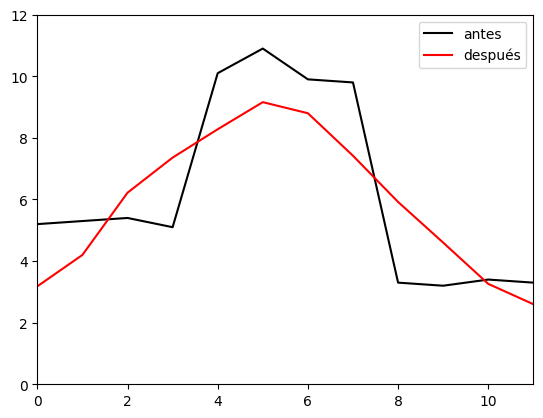

In [107]:

omega2 = [0.2, 0.2, 0.2, 0.2, 0.2]
h4 = conv_5_1_1_zp(x, omega2)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h4):3.3}, debe ser 69.6")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h4, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

In [108]:
# Finalmente, definamos una operación de convolución con relleno de ceros
# con tamaño de kernel 3, paso 1 y dilatación 2.
# Escríbela tú mismo; no llames a una rutina de biblioteca.
# Recuerda que los arreglos de Python se indexan desde cero.
def conv_3_1_2_zp(x_in, omega):
    x_out = np.zeros_like(x_in)
    # TAREA -- escribe esta función
    # reemplaza esta línea
    x_out = x_out


    return x_out

In [109]:
import numpy as np

# --- conv_3_1_2_p: kernel size 3, stride 2, dilation 1, zero padding
def conv_3_1_2_p(x_in, omega):
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    assert len(w) == 3, "omega debe tener tamaño 3"
    N = len(x)
    K = 3
    pad = K // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    stride = 2
    out_len = int(np.ceil(N / stride))
    x_out = np.zeros(out_len, dtype=float)
    out_idx = 0
    # Recorro la señal con paso = stride
    for i in range(0, N, stride):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        x_out[out_idx] = acc
        out_idx += 1
    return x_out

# --- conv_5_1_1_zp: kernel size 5, stride 1, dilation 1, zero padding (salida mismo largo)
def conv_5_1_1_zp(x_in, omega):
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    assert len(w) == 5, "omega debe tener tamaño 5"
    N = len(x)
    K = 5
    pad = K // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    x_out = np.zeros(N, dtype=float)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        x_out[i] = acc
    return x_out

# --- conv_3_1_2_zp: kernel size 3, stride 1, dilation 2, zero padding (salida mismo largo)
def conv_3_1_2_zp(x_in, omega):
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    assert len(w) == 3, "omega debe tener tamaño 3"
    N = len(x)
    K = 3
    dilation = 2
    span = (K - 1) * dilation + 1
    pad = span // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    x_out = np.zeros(N, dtype=float)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            idx = i + j * dilation
            acc += x_padded[idx] * w[j]
        x_out[i] = acc
    return x_out


La suma de la salida es 71.6, debe ser 68.3


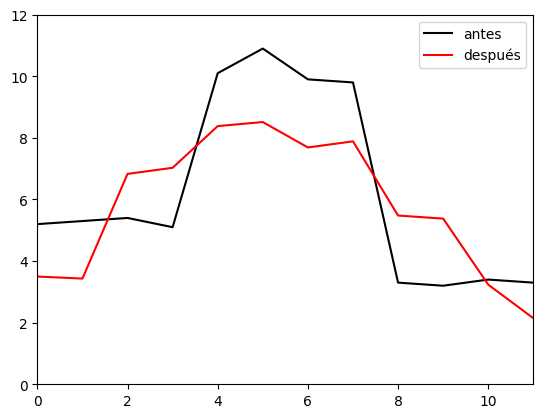

In [110]:
omega = [0.33,0.33,0.33]
h5 = conv_3_1_2_zp(x, omega)

# Comprueba que lo calculaste correctamente
print(f"La suma de la salida es {np.sum(h5):3.3}, debe ser 68.3")

# Dibuja la señal
fig,ax = plt.subplots()
ax.plot(x, 'k-',label='antes')
ax.plot(h5, 'r-',label='después')
ax.set_xlim(0,11)
ax.set_ylim(0, 12)
ax.legend()
plt.show()

Finalmente, representemos las convoluciones como matrices completas y comprobemos que obtenemos el mismo resultado.

In [111]:
# Calcula la matriz de convolución
def get_conv_mat_3_1_1_zp(n_out, omega):
  omega_mat = np.zeros((n_out,n_out))
  # TAREA: completa esta matriz
  # Reemplaza esta línea:
  omega_mat = omega_mat



  return omega_mat

In [112]:
import numpy as np

# -------------------------
# conv_3_1_2_zp
# kernel size 3, stride 1, dilation 2, zero padding, salida mismo largo
# -------------------------
def conv_3_1_2_zp(x_in, omega):
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    assert len(w) == 3, "omega debe tener tamaño 3"
    N = len(x)
    K = 3
    dilation = 2
    span = (K - 1) * dilation + 1          # tamaño efectivo del kernel
    pad = span // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    x_out = np.zeros(N, dtype=float)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            idx = i + j * dilation           # índice en la señal padded
            acc += x_padded[idx] * w[j]
        x_out[i] = acc
    return x_out

# -------------------------
# conv_5_1_1_zp
# kernel size 5, stride 1, dilation 1, zero padding, salida mismo largo
# -------------------------
def conv_5_1_1_zp(x_in, omega):
    x = np.asarray(x_in, dtype=float)
    w = np.asarray(omega, dtype=float)
    assert len(w) == 5, "omega debe tener tamaño 5"
    N = len(x)
    K = 5
    pad = K // 2
    x_padded = np.pad(x, pad_width=pad, mode='constant', constant_values=0.0)
    x_out = np.zeros(N, dtype=float)
    for i in range(N):
        acc = 0.0
        for j in range(K):
            acc += x_padded[i + j] * w[j]
        x_out[i] = acc
    return x_out

# -------------------------
# get_conv_mat_3_1_1_zp
# Construye la matriz de convolución para kernel de tamaño 3,
# stride 1, dilatación 1 y padding con ceros (salida same length)
# -------------------------
def get_conv_mat_3_1_1_zp(n_out, omega):
    omega = np.asarray(omega, dtype=float)
    K = len(omega)
    assert K == 3, "omega debe tener tamaño 3"
    pad = K // 2
    M = np.zeros((n_out, n_out), dtype=float)
    for row in range(n_out):
        for k in range(K):
            col = row + k - pad
            if 0 <= col < n_out:
                M[row, col] = omega[k]
    return M

# -------------------------
# Ejemplo de uso con la señal del cuaderno
# -------------------------
if __name__ == "__main__":
    x = [5.2, 5.3, 5.4, 5.1, 10.1, 10.9, 9.9, 9.8, 3.3, 3.2, 3.4, 3.3, 3.1]

    # kernels de ejemplo
    w3 = [1/3, 1/3, 1/3]          # promedio 3
    w5 = [0.2, 0.2, 0.2, 0.2, 0.2]# promedio 5
    w_test = [-1.0, 0.5, -0.2]    # kernel de prueba para matriz

    y_dil2 = conv_3_1_2_zp(x, w3)
    y_k5 = conv_5_1_1_zp(x, w5)
    M = get_conv_mat_3_1_1_zp(len(x), w_test)
    y_mat = M.dot(np.asarray(x, dtype=float))
    y_conv = np.zeros_like(x, dtype=float)
    # calcular convolución con w_test usando la misma conv 3x1x1 (centro)
    for i in range(len(x)):
        acc = 0.0
        for j in range(3):
            idx = i + j - 1
            if 0 <= idx < len(x):
                acc += x[idx] * w_test[j]
        y_conv[i] = acc

    print("conv_3_1_2_zp (dilation=2):", np.round(y_dil2, 3))
    print("conv_5_1_1_zp (kernel 5):   ", np.round(y_k5, 3))
    print("max abs diff mat vs conv:", np.max(np.abs(y_mat - y_conv)))


conv_3_1_2_zp (dilation=2): [3.533 3.467 6.9   7.1   8.467 8.6   7.767 7.967 5.533 5.433 3.267 2.167
 2.167]
conv_5_1_1_zp (kernel 5):    [3.18 4.2  6.22 7.36 8.28 9.16 8.8  7.42 5.92 4.6  3.26 2.6  1.96]
max abs diff mat vs conv: 8.881784197001252e-16


In [113]:
# Ejecuta la convolución original
omega = np.array([-1.0,0.5,-0.2])
h6 = conv_3_1_1_zp(x, omega)
print(h6)

# Si lo hiciste bien, deberías obtener la misma respuesta
omega_mat = get_conv_mat_3_1_1_zp(len(x), omega)
h7 = np.matmul(omega_mat, x)
print(h7)


[ 1.54 -3.63 -3.62 -4.87 -2.23 -6.63 -7.91 -5.66 -8.79 -2.38 -2.16 -2.37
 -1.75]
[ 1.54 -3.63 -3.62 -4.87 -2.23 -6.63 -7.91 -5.66 -8.79 -2.38 -2.16 -2.37
 -1.75]


TAREA: ¿Qué esperas que ocurra si aplicamos dos veces la última convolución? ¿Se puede representar como una sola convolución? Si es así, ¿cuál sería?